# Path vs Trajectory: TOPP-RA and Ruckig Side by Side

## A path is just geometry. A trajectory adds time.

A **path** from a motion planner is a sequence of joint configurations:
```
[q0, q1, q2, ..., qN]
```
It says *where* to go, but says nothing about *when* or *how fast*. The robot could crawl or sprint — the path is the same.

A **trajectory** assigns a time to every configuration:
```
q(t)  where  t ∈ [0, T]
```
Now we have velocities, accelerations, and a total duration.

**Time parameterization** is the process of converting a path into a trajectory while respecting the robot's dynamic limits (max velocity, max acceleration, and optionally max jerk).

## Two algorithms, different philosophies

| Algorithm | Goal | Key property |
|-----------|------|--------------|
| **TOPP-RA** | Minimize time (time-optimal) | Hits velocity/acceleration limits aggressively — fastest possible motion |
| **Ruckig** | Minimize jerk | Smooth, jerk-limited — better for compliant or force-controlled systems |

Both algorithms take the same path. Both satisfy the same velocity and acceleration limits. But their motion *profiles* look very different — and this notebook shows you why.

In [4]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import matplotlib
# matplotlib_inline 0.2.2 calls rcParams._get() which was removed in newer matplotlib
if not hasattr(matplotlib.RcParams, '_get'):
    matplotlib.RcParams._get = lambda self, key: dict.__getitem__(self, key)

import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [5]:
# Define a 3-waypoint 6-DOF path (same as demos/02_toppra_vs_ruckig.py)
# This is the kind of path a planner would return after finding a collision-free route
DOF = 6

q_start = np.zeros(DOF)                              # home position
q_mid   = np.array([0.3, -0.3, 0.2, -0.4, 0.1, 0.0])  # intermediate waypoint
q_goal  = np.array([0.5, -0.5, 0.3, -0.7, 0.2, 0.0])  # goal

path = [q_start, q_mid, q_goal]

print("Path waypoints:")
for i, q in enumerate(path):
    print(f"  [{i}] {np.round(q, 3)}")

total_dist = sum(np.linalg.norm(path[i+1] - path[i]) for i in range(len(path)-1))
print(f"\nTotal path length (joint-space L2): {total_dist:.4f} rad")
print()
print("Joint velocity and acceleration limits:")
v_max = np.ones(DOF) * 1.0  # 1.0 rad/s per joint
a_max = np.ones(DOF) * 2.0  # 2.0 rad/s^2 per joint
j_max = np.ones(DOF) * 5.0  # 5.0 rad/s^3 (Ruckig only)
print(f"  v_max = {v_max[0]} rad/s")
print(f"  a_max = {a_max[0]} rad/s^2")
print(f"  j_max = {j_max[0]} rad/s^3  (Ruckig only)")

Path waypoints:
  [0] [0. 0. 0. 0. 0. 0.]
  [1] [ 0.3 -0.3  0.2 -0.4  0.1  0. ]
  [2] [ 0.5 -0.5  0.3 -0.7  0.2  0. ]

Total path length (joint-space L2): 1.0604 rad

Joint velocity and acceleration limits:
  v_max = 1.0 rad/s
  a_max = 2.0 rad/s^2
  j_max = 5.0 rad/s^3  (Ruckig only)


In [6]:
from parameterization.toppra_parameterization import ToppraTimeParameterizer

t0 = time.perf_counter()
toppra = ToppraTimeParameterizer(v_max, a_max, n_samples=200)
time_toppra, traj_toppra = toppra.compute(path)
elapsed_toppra = time.perf_counter() - t0

duration_toppra = time_toppra[-1]
print(f"TOPP-RA:")
print(f"  Trajectory duration : {duration_toppra:.4f} s")
print(f"  Trajectory samples  : {len(time_toppra)}")
print(f"  Solver wall time    : {elapsed_toppra*1000:.1f} ms")

TOPP-RA:
  Trajectory duration : 1.2035 s
  Trajectory samples  : 200
  Solver wall time    : 10.3 ms


In [7]:
from parameterization.ruckig_parameterization import RuckigTimeParameterizer

t0 = time.perf_counter()
ruckig_param = RuckigTimeParameterizer(v_max, a_max, j_max)
time_ruckig, traj_ruckig = ruckig_param.compute(path, dt=0.01)
elapsed_ruckig = time.perf_counter() - t0

duration_ruckig = time_ruckig[-1]
print(f"Ruckig:")
print(f"  Trajectory duration : {duration_ruckig:.4f} s")
print(f"  Trajectory samples  : {len(time_ruckig)}")
print(f"  Solver wall time    : {elapsed_ruckig*1000:.1f} ms")

Ruckig:
  Trajectory duration : 1.6400 s
  Trajectory samples  : 165
  Solver wall time    : 5.3 ms


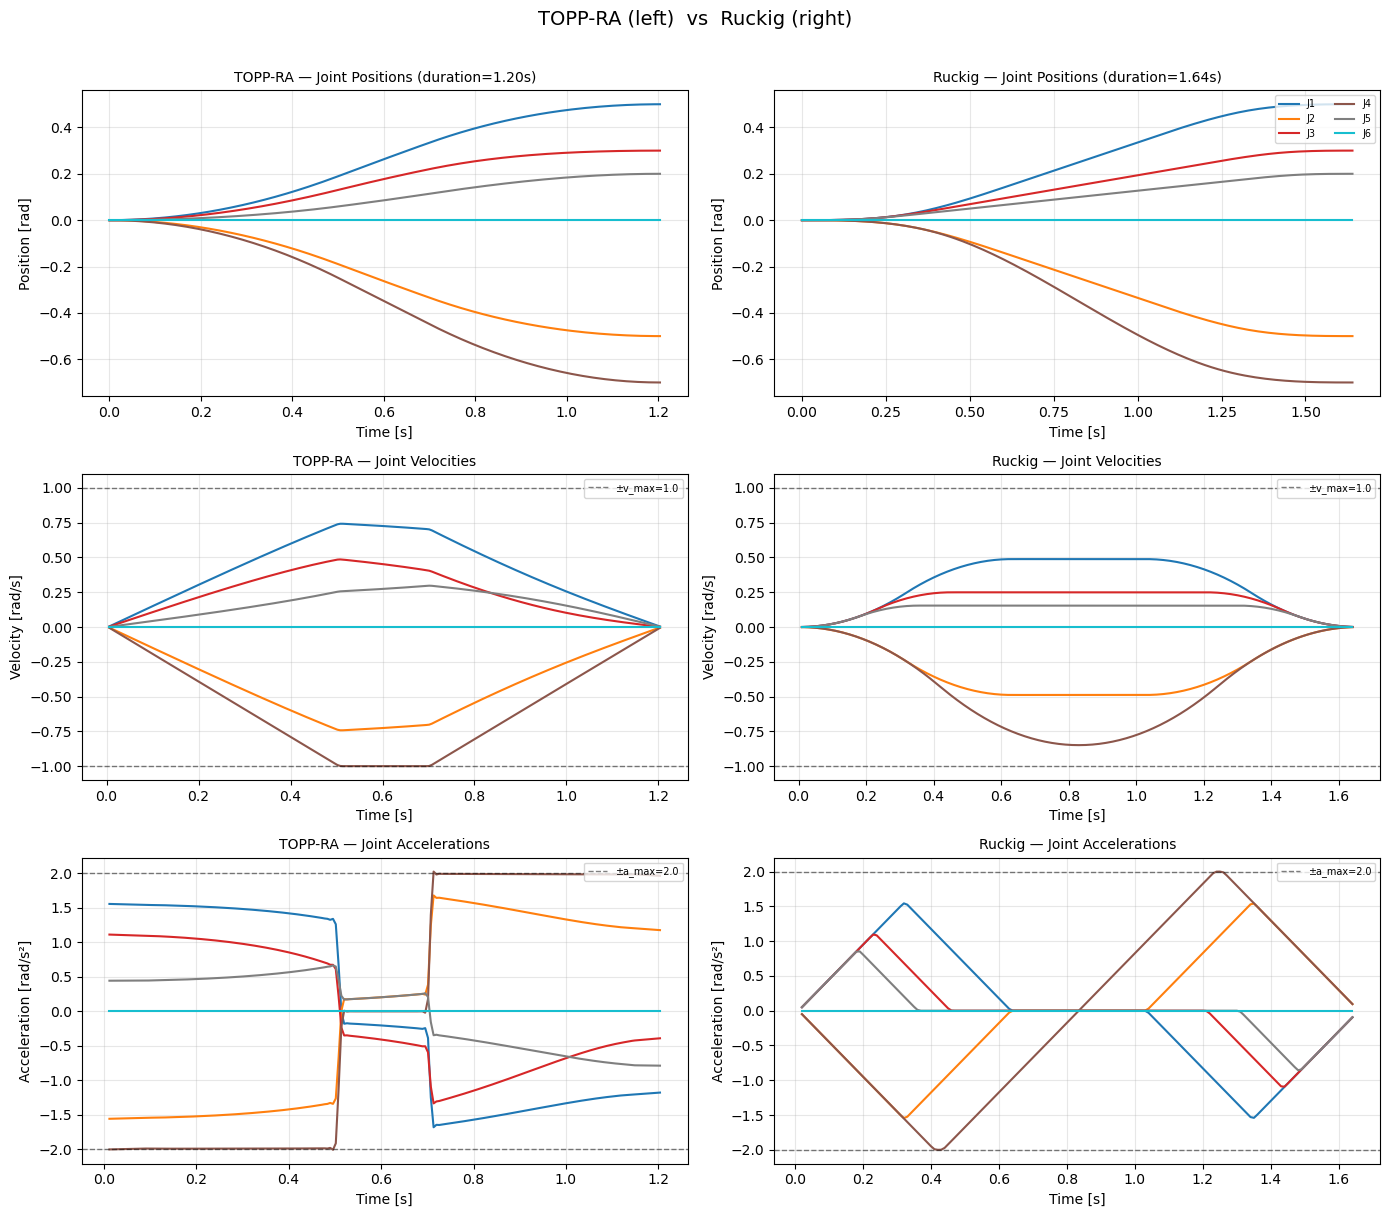

In [8]:
def compute_derivatives(traj, time_arr):
    """Compute velocity and acceleration by finite differences."""
    dt = np.diff(time_arr)
    vel = np.diff(traj, axis=0) / dt[:, None]
    acc = np.diff(vel, axis=0) / dt[:-1][:, None]
    t_vel = time_arr[1:]
    t_acc = time_arr[2:]
    return vel, acc, t_vel, t_acc

vel_t, acc_t, t_vel_t, t_acc_t = compute_derivatives(traj_toppra, time_toppra)
vel_r, acc_r, t_vel_r, t_acc_r = compute_derivatives(traj_ruckig, time_ruckig)

joint_labels = [f'J{i+1}' for i in range(DOF)]
colors = plt.cm.tab10(np.linspace(0, 0.9, DOF))

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('TOPP-RA (left)  vs  Ruckig (right)', fontsize=14, y=1.01)

row_labels = ['Position [rad]', 'Velocity [rad/s]', 'Acceleration [rad/s²]']
row_titles_l = [
    f'TOPP-RA — Joint Positions (duration={duration_toppra:.2f}s)',
    'TOPP-RA — Joint Velocities',
    'TOPP-RA — Joint Accelerations',
]
row_titles_r = [
    f'Ruckig — Joint Positions (duration={duration_ruckig:.2f}s)',
    'Ruckig — Joint Velocities',
    'Ruckig — Joint Accelerations',
]

# Position rows
for j in range(DOF):
    axes[0, 0].plot(time_toppra, traj_toppra[:, j], label=joint_labels[j], color=colors[j])
    axes[0, 1].plot(time_ruckig, traj_ruckig[:, j], label=joint_labels[j], color=colors[j])

# Velocity rows
for j in range(DOF):
    axes[1, 0].plot(t_vel_t, vel_t[:, j], color=colors[j])
    axes[1, 1].plot(t_vel_r, vel_r[:, j], color=colors[j])
# Draw velocity limits
for col in [0, 1]:
    axes[1, col].axhline( v_max[0], color='black', linestyle='--', linewidth=1, alpha=0.5, label=f'±v_max={v_max[0]}')
    axes[1, col].axhline(-v_max[0], color='black', linestyle='--', linewidth=1, alpha=0.5)

# Acceleration rows
for j in range(DOF):
    axes[2, 0].plot(t_acc_t, acc_t[:, j], color=colors[j])
    axes[2, 1].plot(t_acc_r, acc_r[:, j], color=colors[j])
# Draw acceleration limits
for col in [0, 1]:
    axes[2, col].axhline( a_max[0], color='black', linestyle='--', linewidth=1, alpha=0.5, label=f'±a_max={a_max[0]}')
    axes[2, col].axhline(-a_max[0], color='black', linestyle='--', linewidth=1, alpha=0.5)

# Formatting
for row in range(3):
    axes[row, 0].set_title(row_titles_l[row], fontsize=10)
    axes[row, 1].set_title(row_titles_r[row], fontsize=10)
    for col in range(2):
        axes[row, col].set_ylabel(row_labels[row])
        axes[row, col].set_xlabel('Time [s]')
        axes[row, col].grid(alpha=0.3)
    axes[row, 1].legend(loc='upper right', ncol=2, fontsize=7)

axes[1, 0].legend(loc='upper right', fontsize=7)
axes[2, 0].legend(loc='upper right', fontsize=7)
axes[1, 1].legend(loc='upper right', fontsize=7)
axes[2, 1].legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.show()

## Reading the Plots

**TOPP-RA (left column):**
- Velocity profiles hit the limit (`v_max`) and ride it — this is the time-optimal "bang-coast-bang" pattern
- Accelerations switch sharply — TOPP-RA makes piecewise constant acceleration changes
- Duration is shorter because every constraint is used to its maximum

**Ruckig (right column):**
- Velocity profiles have smoother, rounded peaks — jerk is limited so velocities can't change instantaneously
- Accelerations ramp up and down smoothly (triangular or trapezoidal shape)
- Duration is longer because the jerk constraint prevents exploiting the full acceleration budget instantly

Neither algorithm is universally better:
- Use **TOPP-RA** when speed matters (high-throughput automation)
- Use **Ruckig** when smoothness matters (human-robot collaboration, force control, sensitive payloads)

In [9]:
# Compute comparison metrics
def trajectory_metrics(traj, time_arr, label):
    dt = np.diff(time_arr)
    vel = np.diff(traj, axis=0) / dt[:, None]
    acc = np.diff(vel, axis=0) / dt[:-1][:, None]
    
    duration = time_arr[-1]
    max_vel = np.max(np.abs(vel))
    max_acc = np.max(np.abs(acc))
    smoothness = np.std(acc)  # lower = smoother
    
    return {
        'Algorithm': label,
        'Duration (s)': f'{duration:.4f}',
        'Max |velocity| (rad/s)': f'{max_vel:.4f}',
        'Max |acceleration| (rad/s²)': f'{max_acc:.4f}',
        'Smoothness (std of acc)': f'{smoothness:.4f}',
    }

metrics_t = trajectory_metrics(traj_toppra, time_toppra, 'TOPP-RA')
metrics_r = trajectory_metrics(traj_ruckig, time_ruckig, 'Ruckig')

# Print table
keys = list(metrics_t.keys())
col_w = 36
print(f"{'Metric':<{col_w}} {'TOPP-RA':>12}  {'Ruckig':>12}")
print('-' * (col_w + 28))
for k in keys[1:]:
    print(f"{k:<{col_w}} {metrics_t[k]:>12}  {metrics_r[k]:>12}")

print()
print(f"v_max limit = {v_max[0]} rad/s,  a_max limit = {a_max[0]} rad/s^2")
print()
# Compute duration ratio
d_t = float(metrics_t['Duration (s)'])
d_r = float(metrics_r['Duration (s)'])
print(f"Ruckig is {(d_r/d_t - 1)*100:.1f}% slower than TOPP-RA due to jerk limiting.")
print(f"TOPP-RA smoothness (lower is smoother): {metrics_t['Smoothness (std of acc)']}")
print(f"Ruckig  smoothness (lower is smoother): {metrics_r['Smoothness (std of acc)']}")

Metric                                    TOPP-RA        Ruckig
----------------------------------------------------------------
Duration (s)                               1.2035        1.6400
Max |velocity| (rad/s)                     1.0001        0.8490
Max |acceleration| (rad/s²)                2.0250        2.0000
Smoothness (std of acc)                    1.1381        0.7088

v_max limit = 1.0 rad/s,  a_max limit = 2.0 rad/s^2

Ruckig is 36.3% slower than TOPP-RA due to jerk limiting.
TOPP-RA smoothness (lower is smoother): 1.1381
Ruckig  smoothness (lower is smoother): 0.7088


## Exercise

**1. Relaxed velocity limits**  
Change `v_max` to `np.ones(DOF) * 0.5` (half the original speed). Re-run the TOPP-RA and Ruckig cells.
- How does the duration change for each algorithm?
- Which algorithm benefits more from the stricter limit? Which is more affected?
- At `v_max = 0.5`, does TOPP-RA still hit the velocity ceiling?

**2. Intermediate waypoints**  
Add a second intermediate waypoint to the path, e.g.:
```python
q_mid2 = np.array([-0.2, 0.1, -0.1, 0.3, -0.2, 0.1])
path = [q_start, q_mid, q_mid2, q_goal]
```
- Does TOPP-RA handle 4-waypoint paths? (It should — it spline-interpolates)
- Ruckig only uses `path[0]` and `path[-1]` as its start/end. What happens to the intermediate waypoints for Ruckig?

**3. High jerk limits**  
Set `j_max = np.ones(DOF) * 50.0` (very high jerk limit). Does Ruckig now produce a profile similar to TOPP-RA? What does this tell you about the relationship between jerk limiting and time-optimality?